---
date: "2026-05-09"
date-modified: last-modified
format:
  html:
    toc: true
---


# 1. Connections Between Binomial and Hypergeometric

Despite one modeling "with replacement" and the other "without replacement", the [Binomial](bernoulli-and-binomial-distributions.ipynb#the-binomial-distribution) and [Hypergeometric](hypergeometric-distribution.ipynb) distributions are mathematically intertwined.

## 1.1 Conditioning Binomials Yields the Hypergeometric

**Theorem (Fisher Exact Test Structure):** Let $X \sim \text{Bin}(n, p)$ and $Y \sim \text{Bin}(m, p)$ be independent variables. The conditional distribution of $X$, given that their sum is fixed at $X+Y = r$, is exactly $\text{HGeom}(n, m, r)$.

**Proof:**
Using Bayes' Rule and the independence of $X$ and $Y$:

$$P(X=x | X+Y=r) = \frac{P(X+Y=r | X=x)P(X=x)}{P(X+Y=r)}$$

$$= \frac{P(Y = r-x)P(X=x)}{P(X+Y=r)}$$

We proved previously that the sum $X+Y \sim \text{Bin}(n+m, p)$. Substituting the three known PMFs gives:

$$= \frac{\left[ \binom{m}{r-x}p^{r-x}(1-p)^{m-r+x} \right] \left[ \binom{n}{x}p^x(1-p)^{n-x} \right]}{\binom{n+m}{r}p^r(1-p)^{n+m-r}}$$

The $p^r$ and $(1-p)^{n+m-r}$ terms perfectly cancel out of both the numerator and denominator! This leaves:

$$= \frac{\binom{n}{x}\binom{m}{r-x}}{\binom{n+m}{r}}$$

This is exactly the PMF of $\text{HGeom}(n, m, r)$. Fascinatingly, the underlying success probability $p$ completely vanishes from the final conditional distribution. $\square$

## 1.2 The Binomial Limit of the Hypergeometric

**Theorem:** If $X \sim \text{HGeom}(w, b, n)$, and we let the total population size $N = w+b$ approach infinity while maintaining a constant proportion $p = w/N$, the PMF of $X$ mathematically converges to the $\text{Bin}(n, p)$ PMF.

**Proof:**
Start with the Hypergeometric PMF and expand the combinations into factorials:

$$P(X=k) = \binom{n}{k} \frac{w(w-1)\dots(w-k+1) \cdot b(b-1)\dots(b-n+k+1)}{(w+b)(w+b-1)\dots(w+b-n+1)}$$

Divide every term in the large fraction by $N$. There are exactly $n$ terms in the numerator and $n$ terms in the denominator:

$$= \binom{n}{k} \frac{ p(p - \frac{1}{N})\dots(p - \frac{k-1}{N}) \cdot q(q - \frac{1}{N})\dots(q - \frac{n-k-1}{N}) }{ 1(1 - \frac{1}{N})\dots(1 - \frac{n-1}{N}) }$$

As $N \to \infty$, all the fractional terms ($1/N, 2/N$, etc.) shrink to $0$. The limit simplifies to:

$$\lim_{N \to \infty} P(X=k) = \binom{n}{k} \frac{p^k q^{n-k}}{1} = \binom{n}{k} p^k (1-p)^{n-k}$$

Which is precisely the PMF of the Binomial distribution. $\square$

::: {.callout-note title="Intuition: The Infinite Urn"}
If you draw $10$ balls from an urn with $100$ balls without replacement, drawing a white ball tangibly drops the probability of drawing another. But if you draw $10$ balls from an urn containing $1 \text{ million}$ balls, the absence of a few balls doesn't change the remaining probabilities enough to matter. Thus, sampling *without* replacement mathematically converges to sampling *with* replacement as the population size approaches infinity.
:::

## 1.3 Static Visualization

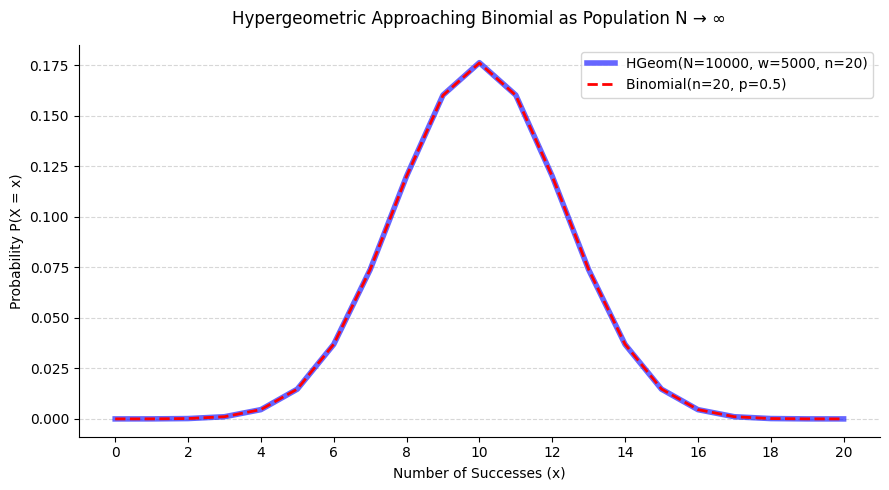

In [1]:
#| label: fig-hypergeom-limit
#| fig-cap: "Convergence of the Hypergeometric distribution to the Binomial distribution for a large population."

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import hypergeom, binom

# Parameters for a large population
w, b, n_trials = 5000, 5000, 20
N = w + b
p = w / N 

x = np.arange(0, n_trials + 1)
hypergeom_pmf = hypergeom.pmf(x, N, w, n_trials)
binomial_pmf = binom.pmf(x, n_trials, p)

fig, ax = plt.subplots(figsize=(9, 5))

# Plot lines to show overlap
ax.plot(x, hypergeom_pmf, 'b-', lw=4, alpha=0.6, label=f'HGeom(N={N}, w={w}, n={n_trials})')
ax.plot(x, binomial_pmf, 'r--', lw=2, label=f'Binomial(n={n_trials}, p={p})')

ax.set_title("Hypergeometric Approaching Binomial as Population N → ∞", pad=15)
ax.set_xlabel("Number of Successes (x)")
ax.set_ylabel("Probability P(X = x)")
ax.set_xticks(np.arange(0, n_trials + 1, 2))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()